In [1]:
#!/usr/bin/env python3
"""
Figure 6: Tumour-Fibrosis Interaction Scenarios
================================================

This script simulates three different scenarios of tumour growth and fibrosis:
- Scenario 1: Tumour only (no fibrosis) (Figure 6f)
- Scenario 2: Fibrosis first, then tumour (Figure 6h)
- Scenario 3: Tumour first, then fibrosis grows from tumour boundary (Figure 6j)

Each scenario can be run on three different expansion replicates (end of expansion 1, 2, or 3).

Usage:
    # Run scenario 1 on expansion 1
    python figure6_script.py --scenario 1 --expansion 1
    
    # Run scenario 2 on expansion 2 with custom parameters
    python figure6_script.py --scenario 2 --expansion 2 --fibrosis-stiffness 2.0 --n-tumour-cells 50
    
    # Run scenario 3 on expansion 3
    python figure6_script.py --scenario 3 --expansion 3 --fibrosis-fraction 0.5

Requirements:
    - Python 3.8+
    - Packages: numpy, matplotlib, scipy, tyssue, pandas
    - The 'src' folder must be in the parent directory
"""


"\nFigure 6: Tumour-Fibrosis Interaction Scenarios\n================================================\n\nThis script simulates three different scenarios of tumour growth and fibrosis:\n- Scenario 1: Tumour only (no fibrosis) (Figure 6f)\n- Scenario 2: Fibrosis first, then tumour (Figure 6h)\n- Scenario 3: Tumour first, then fibrosis grows from tumour boundary (Figure 6j)\n\nEach scenario can be run on three different expansion replicates (end of expansion 1, 2, or 3).\n\nUsage:\n    # Run scenario 1 on expansion 1\n    python figure6_script.py --scenario 1 --expansion 1\n    \n    # Run scenario 2 on expansion 2 with custom parameters\n    python figure6_script.py --scenario 2 --expansion 2 --fibrosis-stiffness 2.0 --n-tumour-cells 50\n    \n    # Run scenario 3 on expansion 3\n    python figure6_script.py --scenario 3 --expansion 3 --fibrosis-fraction 0.5\n\nRequirements:\n    - Python 3.8+\n    - Packages: numpy, matplotlib, scipy, tyssue, pandas\n    - The 'src' folder must be in the

In [2]:
import os
import sys
import pickle
import json
import random
import argparse
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Set
from collections import defaultdict, deque
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.optimize import curve_fit


    
# ============================================================================
# PATH CONFIGURATION
# ============================================================================

def setup_project_root():
    """Set up project root path for imports."""
    try:
        PROJECT_ROOT = Path(__file__).resolve().parent.parent
    except NameError:
        current_dir = Path.cwd()
        PROJECT_ROOT = current_dir
        for _ in range(5):
            if (PROJECT_ROOT / 'src').exists():
                break
            PROJECT_ROOT = PROJECT_ROOT.parent
    
    sys.path.insert(0, str(PROJECT_ROOT))
    
    if not (PROJECT_ROOT / 'src').exists():
        raise FileNotFoundError(
            f"src folder not found at {PROJECT_ROOT / 'src'}. "
            f"Please check your project structure."
        )
    
    print(f"Project root: {PROJECT_ROOT}")
    return PROJECT_ROOT

PROJECT_ROOT = setup_project_root()

# Import project modules
import src.auxFunctions as auxFunctions
import src.inputMechanicalParametersModel2 as MechanicalParams2
import src.vertexModel2 as vertexModel2
import src.auxFunctionsExpansion as auxFunctionsExpansion
from tyssue.draw import sheet_view

# ============================================================================
# CHECKPOINT MANAGEMENT
# ============================================================================

# Base path for simulations (from your current location in /notebooks)
SIMULATION_BASE_PATH = "Simulations_with_remodelling_every_1000th_cycle"

# Define the three expansion checkpoints with correct folder names
EXPANSION_CHECKPOINTS = {
    1: {
        'path': f"{SIMULATION_BASE_PATH}/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_div_3.5_1/checkpoint_015000.pkl",
        'description': 'End of expansion 1',
        'seed': 1
    },
    2: {
        'path': f"{SIMULATION_BASE_PATH}/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_div_3.5_2/checkpoint_015000.pkl",
        'description': 'End of expansion 2',
        'seed': 2
    },
    3: {
        'path': f"{SIMULATION_BASE_PATH}/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_div_3.5_3/checkpoint_015000.pkl",
        'description': 'End of expansion 3',
        'seed': 3
    }
}

def load_checkpoint(expansion_number):
    """
    Load checkpoint for a specific expansion replicate.
    
    Parameters:
    -----------
    expansion_number : int
        Which expansion to load (1, 2, or 3)
    
    Returns:
    --------
    cellmap : object
        Loaded cellmap from checkpoint
    """
    if expansion_number not in EXPANSION_CHECKPOINTS:
        raise ValueError(f"Expansion {expansion_number} not found. Available: {list(EXPANSION_CHECKPOINTS.keys())}")
    
    checkpoint_path = EXPANSION_CHECKPOINTS[expansion_number]['path']
    description = EXPANSION_CHECKPOINTS[expansion_number]['description']
    
    print(f"\n Loading checkpoint: {description}")
    print(f"   Path: {checkpoint_path}")
    
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    
    with open(checkpoint_path, 'rb') as f:
        cellmap = pickle.load(f)
    
    print(f"   Loaded successfully")
    print(f"   Tissue has {len(cellmap.face_df)} cells, {len(cellmap.vert_df)} vertices")
    
    return cellmap

# ============================================================================
# AUXILIARY FUNCTIONS (Shared across scenarios)
# ============================================================================

def build_face_adjacency(sheet):
    """Build face adjacency dictionary via shared undirected edges."""
    und2faces = defaultdict(set)
    for _, row in sheet.edge_df[["srce", "trgt", "face"]].iterrows():
        f = row["face"]
        if np.isnan(f):
            continue
        s = int(row["srce"]); t = int(row["trgt"]); f = int(f)
        key = (s, t) if s < t else (t, s)
        und2faces[key].add(f)

    adj = defaultdict(set)
    for faces in und2faces.values():
        faces = list(faces)
        if len(faces) >= 2:
            for i in range(len(faces)):
                for j in range(i + 1, len(faces)):
                    a, b = faces[i], faces[j]
                    adj[a].add(b); adj[b].add(a)
    return adj


def choose_subcapsular_seeds(cellmap, n_seeds=5, seed=0, n_layers=1):
    """Pick tumour seeds from the subcapsular band."""
    boundary_edges, boundary_faces, inside_edges, outside_edges, inside_faces, inside_vertices, outside_vertices = (
        auxFunctions.identify_boundary_layers(cellmap, n_layers)
    )

    face_adj = build_face_adjacency(cellmap)

    boundary_set = set(map(int, boundary_faces))
    inside_set = set(map(int, inside_faces))

    subcapsular_faces = set()
    for bf in boundary_set:
        for nb in face_adj.get(int(bf), set()):
            if int(nb) in inside_set:
                subcapsular_faces.add(int(nb))

    subcapsular_faces = np.array(sorted(subcapsular_faces), dtype=int)
    rng = np.random.default_rng(seed)

    if len(subcapsular_faces) == 0:
        raise RuntimeError("No subcapsular faces found. Check boundary layer logic.")

    n_seeds = min(int(n_seeds), len(subcapsular_faces))
    tumour_seed_faces = rng.choice(subcapsular_faces, size=n_seeds, replace=False)
    return tumour_seed_faces, face_adj, subcapsular_faces


def grow_tumour_random_frontier(face_adj, seed_faces, n_add, p_frontier=0.9, random_seed=None):
    """
    Grow an irregular tumour by adding faces one-by-one from multiple seeds.
    
    Parameters:
    -----------
    face_adj : dict
        Face adjacency dictionary
    seed_faces : list or int
        Starting face ID(s) for tumour growth
    n_add : int
        Number of faces to add PER SEED
    p_frontier : float
        Probability of adding frontier cells (close to 1 = tendrils)
    random_seed : int, optional
        Random seed for reproducibility
    
    Returns:
    --------
    tumour : set
        Set of all face IDs in the tumour
    """
    if random_seed is not None:
        random.seed(random_seed)
    
    # Handle single seed face
    if isinstance(seed_faces, (int, float)):
        seed_faces = [int(seed_faces)]
    
    seed_faces = [int(s) for s in seed_faces]
    tumour = set(seed_faces)
    
    # Initialize frontier
    frontier = set()
    for seed in seed_faces:
        frontier.update(face_adj.get(seed, set()))
    frontier -= tumour
    
    # Calculate total cells to add
    total_to_add = len(seed_faces) * int(n_add)
    
    # Grow tumour
    while len(tumour) - len(seed_faces) < total_to_add and frontier:
        nxt = random.choice(list(frontier))
        frontier.remove(nxt)
        
        if nxt in tumour:
            continue
        
        tumour.add(nxt)
        
        for nb in face_adj.get(nxt, set()):
            if nb not in tumour:
                frontier.add(int(nb))
        
        # Occasionally add non-frontier cells for irregular shape
        if random.random() > p_frontier:
            candidates = set()
            for f in tumour:
                candidates |= set(face_adj.get(int(f), set()))
            candidates -= tumour
            if candidates:
                tumour.add(random.choice(list(candidates)))
    
    return tumour


def create_fibrotic_patches(
    sheet,
    fraction=0.5,
    ecm_stiffness_factor=1000.0,
    pl_factor=0.001,
    n_patches=6,
    seed=42
):
    """
    Create disconnected fibrotic patches (Scenario 2).
    """
    rng = np.random.default_rng(seed)
    
    # Identify inside edges
    from src.auxFunctions import identify_boundary_layers
    (_, _, inside_edges, _, _, _, _) = identify_boundary_layers(sheet, 0)
    eligible_edges = list(sheet.edge_df.index.intersection(inside_edges))
    
    print(f"  Total inside edges: {len(eligible_edges)}")
    
    if len(eligible_edges) == 0:
        return []
    
    # Build adjacency
    v2edges = defaultdict(set)
    for eid in eligible_edges:
        s = sheet.edge_df.loc[eid, 'srce']
        t = sheet.edge_df.loc[eid, 'trgt']
        v2edges[s].add(eid)
        v2edges[t].add(eid)
    
    adj = {eid: set() for eid in eligible_edges}
    for edges in v2edges.values():
        edges_list = list(edges)
        for i, e1 in enumerate(edges_list):
            for e2 in edges_list[i+1:]:
                adj[e1].add(e2)
                adj[e2].add(e1)
    
    # Calculate target
    n_target = int(np.round(fraction * len(eligible_edges)))
    n_target = max(n_target, n_patches)
    print(f"  Target edges: {n_target}")
    
    # Allocate patch sizes
    base = n_target / n_patches
    raw = base * (1 + 0.25 * rng.normal(size=n_patches))
    raw = np.clip(raw, 1, None)
    sizes = np.floor(raw).astype(int)
    
    while sizes.sum() < n_target:
        sizes[rng.integers(0, n_patches)] += 1
    while sizes.sum() > n_target:
        i = rng.integers(0, n_patches)
        if sizes[i] > 1:
            sizes[i] -= 1
    
    # Grow patches
    forbidden = set()
    all_patches = []
    remaining_edges = list(eligible_edges)
    rng.shuffle(remaining_edges)
    
    for patch_idx, patch_size in enumerate(sizes):
        seed_edge = None
        for e in remaining_edges:
            if e not in forbidden:
                seed_edge = e
                break
        
        if seed_edge is None:
            break
        
        patch = set()
        queue = deque([seed_edge])
        
        while queue and len(patch) < patch_size:
            e = queue.popleft()
            if e in forbidden or e in patch:
                continue
            patch.add(e)
            neighbours = list(adj.get(e, set()))
            rng.shuffle(neighbours)
            for nbr in neighbours:
                if nbr not in forbidden and nbr not in patch:
                    queue.append(nbr)
        
        forbidden |= patch
        all_patches.append(patch)
    
    # Collect all fibrotic edges (both directions)
    all_fibrotic_edges = set()
    for patch in all_patches:
        all_fibrotic_edges.update(patch)
    
    fibrotic_edges_both = set()
    for eid in all_fibrotic_edges:
        fibrotic_edges_both.add(eid)
        s = sheet.edge_df.loc[eid, 'srce']
        t = sheet.edge_df.loc[eid, 'trgt']
        rev = sheet.edge_df[(sheet.edge_df['srce'] == t) & (sheet.edge_df['trgt'] == s)].index
        fibrotic_edges_both.update(rev)
    
    # Apply properties
    sheet.edge_df.loc[list(fibrotic_edges_both), 'length_elasticity'] *= ecm_stiffness_factor
    sheet.edge_df.loc[list(fibrotic_edges_both), 'prefered_length'] *= pl_factor
    sheet.edge_df.loc[list(fibrotic_edges_both), 'line_tension'] *= ecm_stiffness_factor
    sheet.edge_df['is_fibrotic'] = 0
    sheet.edge_df.loc[list(fibrotic_edges_both), 'is_fibrotic'] = 1
    
    print(f"  Created {len(all_patches)} patches with {len(fibrotic_edges_both)} half-edges")
    
    return list(fibrotic_edges_both)


def grow_fibrotic_from_tumour(
    sheet,
    tumour_faces,
    fraction=0.5,
    ecm_stiffness_factor=100.0,
    pl_factor=0.01,
    seed=42
):
    """
    Grow fibrotic patches outward from tumour boundary (Scenario 3).
    """
    rng = np.random.default_rng(seed)
    tumour_set = set(tumour_faces)
    
    # Find tumour boundary edges
    und2faces = defaultdict(set)
    und2eids = defaultdict(list)
    
    for eid, row in sheet.edge_df[["srce", "trgt", "face"]].iterrows():
        f = row["face"]
        if np.isnan(f):
            continue
        s = int(row["srce"]); t = int(row["trgt"]); f = int(f)
        k = (s, t) if s < t else (t, s)
        und2faces[k].add(f)
        und2eids[k].append(int(eid))
    
    boundary_undirected = set()
    for k, faces in und2faces.items():
        if len(faces) >= 2:
            n_tum = sum(1 for f in faces if f in tumour_set)
            if n_tum == 1:
                boundary_undirected.add(k)
    
    boundary_halfedges = set()
    for k in boundary_undirected:
        for eid, f in zip(und2eids[k], list(und2faces[k])):
            if f not in tumour_set:
                boundary_halfedges.add(eid)
    
    print(f"  Tumour boundary edges: {len(boundary_halfedges)}")
    
    # Build vertex-edge adjacency
    v2e = defaultdict(set)
    for eid in sheet.edge_df.index:
        s = int(sheet.edge_df.loc[eid, 'srce'])
        t = int(sheet.edge_df.loc[eid, 'trgt'])
        v2e[s].add(eid)
        v2e[t].add(eid)
    
    # Grow outward
    total_edges = len(sheet.edge_df)
    target_fibrotic = int(np.round(fraction * total_edges))
    print(f"  Target: {target_fibrotic} half-edges ({fraction*100:.0f}% of {total_edges})")
    
    fibrotic_edges = set(boundary_halfedges)
    frontier = set(boundary_halfedges)
    visited = set(boundary_halfedges)
    
    while len(fibrotic_edges) < target_fibrotic and frontier:
        new_frontier = set()
        for e in frontier:
            s = int(sheet.edge_df.loc[e, 'srce'])
            t = int(sheet.edge_df.loc[e, 'trgt'])
            new_frontier.update(v2e[s])
            new_frontier.update(v2e[t])
        
        new_frontier -= visited
        
        new_list = list(new_frontier)
        rng.shuffle(new_list)
        
        needed = target_fibrotic - len(fibrotic_edges)
        to_add = new_list[:min(needed, len(new_list))]
        
        fibrotic_edges.update(to_add)
        visited.update(to_add)
        frontier = set(to_add)
    
    # Add reverse half-edges
    fibrotic_edges_both = set()
    for eid in fibrotic_edges:
        fibrotic_edges_both.add(eid)
        s = sheet.edge_df.loc[eid, 'srce']
        t = sheet.edge_df.loc[eid, 'trgt']
        rev = sheet.edge_df[(sheet.edge_df['srce'] == t) & (sheet.edge_df['trgt'] == s)].index
        fibrotic_edges_both.update(rev)
    
    # Apply properties
    sheet.edge_df.loc[list(fibrotic_edges_both), 'length_elasticity'] *= ecm_stiffness_factor
    sheet.edge_df.loc[list(fibrotic_edges_both), 'prefered_length'] *= pl_factor
    sheet.edge_df.loc[list(fibrotic_edges_both), 'line_tension'] *= ecm_stiffness_factor
    sheet.edge_df['is_fibrotic'] = 0
    sheet.edge_df.loc[list(fibrotic_edges_both), 'is_fibrotic'] = 1
    
    print(f"  Final: {len(fibrotic_edges_both)} half-edges modified")
    
    return list(fibrotic_edges_both)


def divide_vertices(
    cellmap,
    geom,
    energy_model,
    next_edge_uid,
    after_tumour=True,
    inside_vertices=None,
    edge_sum_threshold=4,
    division_distance=0.01,
    output_folder="vertex_division_results"
):
    """Divide vertices above threshold."""
    os.makedirs(output_folder, exist_ok=True)
    cellmap_work = cellmap.copy()
    
    if 'after_tumour' not in cellmap_work.vert_df.columns:
        cellmap_work.vert_df['after_tumour'] = False
    
    original_vertex_ids = set(cellmap_work.vert_df.index)
    
    if inside_vertices is None:
        from src.auxFunctions import identify_boundary_layers
        (_, _, _, _, _, inside_vertices, _) = identify_boundary_layers(cellmap_work, 1)
    
    vertices_to_divide = auxFunctionsExpansion.identify_vertices_to_divide(
        cellmap_work, inside_vertices, edge_sum_threshold
    )
    
    print(f"  Vertices to divide: {len(vertices_to_divide)}")
    
    if len(vertices_to_divide) == 0:
        return cellmap_work, [], next_edge_uid
    
    cellmap_work, chosen_vertices, new_vertices, next_edge_uid = auxFunctionsExpansion.perform_divisions(
        cellmap_work, vertices_to_divide, next_edge_uid, geom, energy_model, division_distance
    )
    
    if new_vertices:
        for v in new_vertices:
            if v in cellmap_work.vert_df.index:
                cellmap_work.vert_df.at[v, 'after_tumour'] = after_tumour
    
    cellmap_work.reset_index()
    cellmap_work.reset_topo()
    
    return cellmap_work, chosen_vertices, next_edge_uid


def apply_tumour_mechanics(cellmap, tumour_faces, area_multiplier=1, elasticity_multiplier=5):
    """Apply tumour cell mechanical properties."""
    tumour_list = list(tumour_faces)
    cellmap.face_df.loc[tumour_list, "prefered_area"] *= area_multiplier
    cellmap.face_df.loc[tumour_list, "area_elasticity"] *= elasticity_multiplier
    return cellmap


def apply_capsule_remodelling(cellmap, n_layers=1, viscosity=2000000):
    """Apply capsule remodelling at boundary."""
    _, _, _, _, _, _, outside_vertices = auxFunctions.identify_boundary_layers(cellmap, n_layers)
    cellmap.vert_df.loc[outside_vertices, "viscosity"] = viscosity
    return cellmap


def relax_tissue(cellmap, geom, energy_model, steps=200):
    """Relax tissue for given number of steps."""
    # Make sure energy_model has compute_energy
    if not hasattr(energy_model, 'compute_energy'):
        print("Warning: energy_model missing compute_energy, recreating")
        from tyssue.dynamics import effectors, model_factory
        energy_model = model_factory([
            effectors.FaceAreaElasticity,
            effectors.LineTension,
            effectors.LengthElasticity,
        ])
        cellmap.update_specs(energy_model.specs)
    
    # Compute energy and solve
    energy_model.compute_energy(cellmap)
    cellmap, geom, energy_model, history, solver = vertexModel2.solveEuler(
        cellmap, geom, energy_model, steps
    )
    return cellmap, geom, energy_model, history

# ============================================================================
# PLOTTING FUNCTIONS
# ============================================================================

def setup_colormaps():
    """Register custom colormaps for plotting."""
    face_cmap = LinearSegmentedColormap.from_list('face_cmap', ['white', 'darkgrey'])
    plt.colormaps.register(face_cmap, name='my_face_cmap', force=True)
    
    edge_cmap = LinearSegmentedColormap.from_list('edge_cmap', ['mediumturquoise', 'mediumvioletred'])
    plt.colormaps.register(edge_cmap, name='my_edge_cmap', force=True)
    print("Colormaps registered")


def plot_tissue(
    sheet,
    tumour_faces=None,
    fibrotic_edges=None,
    show_after_tumour_vertices=False,
    tumour_threshold=100,
    stiffness_threshold=150,
    xlim=(-20, 60),
    ylim=(-20, 60),
    figsize=(15, 15),
    vertex_size=30,
    show_only_new_vertices=False,
    title=None,
    save_path=None
):
    """
    Unified plotting function for all scenarios.
    """
    if tumour_faces is None:
        tumour_faces = []
    if fibrotic_edges is None:
        fibrotic_edges = []
    
    # Face colors
    if len(tumour_faces) > 0:
        face_colors_num = np.zeros(len(sheet.face_df.index))
        tumour_set = set(tumour_faces)
        for i, face_id in enumerate(sheet.face_df.index):
            face_colors_num[i] = 1.0 if face_id in tumour_set else 0.0
        
        face_spec = {
            'visible': True,
            'color': face_colors_num,
            'colormap': 'my_face_cmap',
            'alpha': 1.0,
        }
    else:
        face_spec = {'visible': True, 'color': 'white', 'alpha': 1.0}
    
    # Edge colors
    if len(fibrotic_edges) > 0:
        edge_colors_num = np.zeros(len(sheet.edge_df.index))
        fibrotic_set = set(fibrotic_edges)
        for i, edge_id in enumerate(sheet.edge_df.index):
            edge_colors_num[i] = 1.0 if edge_id in fibrotic_set else 0.0
        
        edge_spec = {
            'visible': True,
            'color': edge_colors_num,
            'colormap': 'my_edge_cmap',
            'width': 2.5,
            'alpha': 1.0,
        }
    else:
        edge_spec = {
            'visible': True,
            'color': 'mediumturquoise',
            'width': 2.5,
            'alpha': 1.0,
        }
    
    specs = {
        'face': face_spec,
        'edge': edge_spec,
        'vert': {'visible': False}
    }
    
    fig, ax = sheet_view(sheet, **specs)
    fig.set_size_inches(figsize)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Plot after-tumour vertices if requested
    after_tumour_count = 0
    if show_after_tumour_vertices and 'after_tumour' in sheet.vert_df.columns:
        for vert_id in sheet.vert_df.index:
            x = sheet.vert_df.loc[vert_id, 'x']
            y = sheet.vert_df.loc[vert_id, 'y']
            
            if sheet.vert_df.loc[vert_id, 'after_tumour']:
                ax.scatter(x, y, c='red', s=vertex_size, zorder=5, 
                          edgecolors='darkred', linewidth=0.5)
                after_tumour_count += 1
            elif not show_only_new_vertices:
                ax.scatter(x, y, c='dimgrey', s=vertex_size * 0.6, zorder=5, alpha=0.6)
    
    # Set title
    if title is None:
        title = f"Tumour cells: {len(tumour_faces)} | Fibrotic edges: {len(fibrotic_edges)}"
        if show_after_tumour_vertices:
            title += f" | New vertices: {after_tumour_count}"
    ax.set_title(title, fontsize=14)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Figure saved to: {save_path}")
    
    return fig, ax


# ============================================================================
# MAIN SCENARIO FUNCTIONS
# ============================================================================

def run_scenario_1(cellmap, geom, energy_model, params, expansion_num):
    """
    Scenario 1: Tumour only (no fibrosis) with intermediate plots
    """
    print("\n" + "="*60)
    print(f"SCENARIO 1: Tumour Only (Expansion {expansion_num})")
    print("="*60)
    
    # Create output directory for plots
    plot_dir = f"{params['output_folder']}/scenario1_exp{expansion_num}"
    os.makedirs(plot_dir, exist_ok=True)
    
    # PLOT 1: Original tissue (before any modifications)
    print("\n PLOT 1: Original tissue after expansion")
    fig1, ax1 = plot_tissue(
        cellmap,
        tumour_faces=[],
        fibrotic_edges=[],
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Original Tissue - Expansion {expansion_num}\n(before tumour seeding)"
    )
    plt.savefig(f"{plot_dir}/01_original_tissue.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig1)
    
    # Seed tumour
    print("\n Selecting tumour seeds")
    tumour_seed_faces, face_adj, _ = choose_subcapsular_seeds(
        cellmap, n_seeds=params['n_seeds'], 
        seed=params['seed'], n_layers=1
    )
    print(f"   Selected {len(tumour_seed_faces)} seed cells")
    
    # PLOT 2: Seeded tumour cells (before growth)
    print("\n PLOT 2: Seeded tumour cells (before growth)")
    temp_tumour = set(tumour_seed_faces)
    fig2, ax2 = plot_tissue(
        cellmap,
        tumour_faces=list(temp_tumour),
        fibrotic_edges=[],
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Seeded Tumour Cells - Expansion {expansion_num}\n{len(tumour_seed_faces)} seeds (before growth)"
    )
    plt.savefig(f"{plot_dir}/02_seeded_tumour.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig2)
    
    # Grow tumour
    print(f"\n Growing tumour ({params['n_tumour_cells_per_seed']} cells per seed)")
    tumour = grow_tumour_random_frontier(
        face_adj, tumour_seed_faces, params['n_tumour_cells_per_seed'],
        p_frontier=params['p_frontier'], random_seed=params['seed']
    )
    print(f"   Final tumour size: {len(tumour)} cells")
    
    # PLOT 3: Grown tumour cells (before relaxation)
    print("\n PLOT 3: Grown tumour cells (before relaxation)")
    fig3, ax3 = plot_tissue(
        cellmap,
        tumour_faces=list(tumour),
        fibrotic_edges=[],
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Grown Tumour - Expansion {expansion_num}\n{len(tumour)} cells (before relaxation)"
    )
    plt.savefig(f"{plot_dir}/03_grown_tumour_before_relax.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig3)
    
    # Apply mechanics
    print("\n Applying tumour mechanics")
    cellmap = apply_tumour_mechanics(cellmap, tumour)
    cellmap = apply_capsule_remodelling(cellmap)
    
    # Relax
    print(f"\n Relaxing energy for {params['relaxation_steps']} steps")
    print("Relaxing")
    cellmap, geom, energy_model, history = relax_tissue(
        cellmap, geom, energy_model, params['relaxation_steps']
    )
    print("   Relaxation complete")
    
    # PLOT 4: After relaxation
    print("\n PLOT 4: After energy relaxation")
    tumour_faces = cellmap.face_df[
        cellmap.face_df['area_elasticity'] > 100
    ].index.tolist()
    fig4, ax4 = plot_tissue(
        cellmap,
        tumour_faces=tumour_faces,
        fibrotic_edges=[],
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"After Relaxation - Expansion {expansion_num}\nTumour: {len(tumour_faces)} cells"
    )
    plt.savefig(f"{plot_dir}/04_after_relaxation.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig4)
    
    # Division
    print(f"\n Dividing vertices (threshold={params['division_threshold']})")
    if 'edge_uid' in cellmap.edge_df.columns:
        next_edge_uid = int(cellmap.edge_df['edge_uid'].max()) + 1
    else:
        cellmap.edge_df['edge_uid'] = range(len(cellmap.edge_df))
        next_edge_uid = len(cellmap.edge_df)
    
    cellmap, _, next_edge_uid = divide_vertices(
        cellmap, geom, energy_model, next_edge_uid,
        after_tumour=True, edge_sum_threshold=params['division_threshold'],
        output_folder=f"{params['output_folder']}/scenario1_exp{expansion_num}"
    )
    print("Vertex division complete")
    
    # PLOT 4b: After vertex division (before final relaxation)
    print("\n PLOT 4b: After vertex division (before final relaxation)")
    tumour_faces = cellmap.face_df[
        cellmap.face_df['area_elasticity'] > 100
    ].index.tolist()
    fig4b, ax4b = plot_tissue(
        cellmap,
        tumour_faces=tumour_faces,
        fibrotic_edges=[],
        show_after_tumour_vertices=True,
        show_only_new_vertices=True,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"After Vertex Division - Expansion {expansion_num}\nRed vertices = newly created"
    )
    plt.savefig(f"{plot_dir}/04b_after_division.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig4b)
    
    # Final relaxation
    print(f"\n Final relaxation for {params['post_division_steps']} steps")
    print("Relaxing")
    cellmap, geom, energy_model, history_final = relax_tissue(
        cellmap, geom, energy_model, params['post_division_steps']
    )
    print("Complete")
    
    # PLOT 5: Final result
    print("\n PLOT 5: Final result")
    final_tumour_faces = cellmap.face_df[
        cellmap.face_df['area_elasticity'] > 100
    ].index.tolist()
    fig5, ax5 = plot_tissue(
        cellmap,
        tumour_faces=final_tumour_faces,
        fibrotic_edges=[],
        show_after_tumour_vertices=True,
        show_only_new_vertices=True,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(15, 15),
        title=f"FINAL - Scenario 1 | Expansion {expansion_num}\nTumour: {len(final_tumour_faces)} cells | New vertices shown in red",
        save_path=f"{plot_dir}/05_final_result.png"
    )
    plt.show()
    plt.close(fig5)
    
    print(f"\n All plots saved to: {plot_dir}/")
    
    return cellmap, final_tumour_faces, []

def run_scenario_2(cellmap, geom, energy_model, params, expansion_num):
    """
    Scenario 2: Fibrosis first, then tumour with intermediate plots
    """
    print("\n" + "="*60)
    print(f"SCENARIO 2: Fibrosis First, Then Tumour (Expansion {expansion_num})")
    print("="*60)
    
    # Create output directory for plots
    plot_dir = f"{params['output_folder']}/scenario2_exp{expansion_num}"
    os.makedirs(plot_dir, exist_ok=True)
    
    # PLOT 1: Original tissue (before any modifications)
    print("\n PLOT 1: Original tissue after expansion")
    fig1, ax1 = plot_tissue(
        cellmap,
        tumour_faces=[],
        fibrotic_edges=[],
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Original Tissue - Expansion {expansion_num}\n(before any modifications)"
    )
    plt.savefig(f"{plot_dir}/01_original_tissue.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig1)
    
    # Step 1: Create fibrotic patches
    print("\n[Step 1] Creating fibrotic patches")
    print(f"   Creating {params['n_fibrotic_patches']} patches with {params['fibrosis_fraction']*100:.0f}% of edges")
    
    fibrotic_edges = create_fibrotic_patches(
        cellmap,
        fraction=params['fibrosis_fraction'],
        ecm_stiffness_factor=params['fibrosis_stiffness_factor'],
        pl_factor=params['fibrosis_pl_factor'],
        n_patches=params['n_fibrotic_patches'],
        seed=params['seed']
    )
    print(f"  Created {len(fibrotic_edges)} fibrotic half-edges")
    
    # PLOT 2: Fibrotic patches (before relaxation)
    print("\n PLOT 2: Fibrotic patches (before relaxation)")
    fig2, ax2 = plot_tissue(
        cellmap,
        tumour_faces=[],
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Fibrotic Patches - Expansion {expansion_num}\n{len(fibrotic_edges)} fibrotic edges (before relaxation)"
    )
    plt.savefig(f"{plot_dir}/02_fibrotic_patches_before_relax.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig2)
    
    # Relax after fibrosis
    print(f"\n Relaxing energy for {params['relaxation_steps']} steps (after fibrosis)")
    print("Relaxing")
    cellmap, geom, energy_model, _ = relax_tissue(
        cellmap, geom, energy_model, params['relaxation_steps']
    )
    print("  Relaxation complete")
    
    # PLOT 3: After fibrosis relaxation
    print("\n PLOT 3: After fibrosis relaxation")
    # Update fibrotic edges (they might have changed)
    if 'is_fibrotic' in cellmap.edge_df.columns:
        fibrotic_edges = cellmap.edge_df[cellmap.edge_df['is_fibrotic'] == 1].index.tolist()
    
    fig3, ax3 = plot_tissue(
        cellmap,
        tumour_faces=[],
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"After Fibrosis Relaxation - Expansion {expansion_num}\nFibrotic edges: {len(fibrotic_edges)}"
    )
    plt.savefig(f"{plot_dir}/03_after_fibrosis_relax.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig3)
    
    # Step 2: Seed and grow tumour
    print("\n[Step 2] Growing tumour")
    
    # Select seeds
    tumour_seed_faces, face_adj, _ = choose_subcapsular_seeds(
        cellmap, n_seeds=params['n_seeds'],
        seed=params['seed'], n_layers=1
    )
    print(f"   Selected {len(tumour_seed_faces)} seed cells")
    
    # PLOT 4: Seeded tumour cells (before growth)
    print("\n PLOT 4: Seeded tumour cells (before growth)")
    temp_tumour = set(tumour_seed_faces)
    fig4, ax4 = plot_tissue(
        cellmap,
        tumour_faces=list(temp_tumour),
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Seeded Tumour Cells - Expansion {expansion_num}\n{len(tumour_seed_faces)} seeds (before growth)"
    )
    plt.savefig(f"{plot_dir}/04_seeded_tumour.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig4)
    
    # Grow tumour
    print(f"\n Growing tumour ({params['n_tumour_cells_per_seed']} cells per seed)")
    tumour = grow_tumour_random_frontier(
        face_adj, tumour_seed_faces, params['n_tumour_cells_per_seed'],
        p_frontier=params['p_frontier'], random_seed=params['seed']
    )
    print(f"   Final tumour size: {len(tumour)} cells")
    
    # PLOT 5: Grown tumour (before relaxation)
    print("\n PLOT 5: Grown tumour (before relaxation)")
    fig5, ax5 = plot_tissue(
        cellmap,
        tumour_faces=list(tumour),
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Grown Tumour - Expansion {expansion_num}\n{len(tumour)} cells (before relaxation)"
    )
    plt.savefig(f"{plot_dir}/05_grown_tumour_before_relax.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig5)
    
    # Apply tumour mechanics
    print("\n Applying tumour mechanics")
    cellmap = apply_tumour_mechanics(cellmap, tumour)
    cellmap = apply_capsule_remodelling(cellmap)
    
    # Relax after tumour growth
    print(f"\n Relaxing energy for {params['relaxation_steps']} steps (after tumour)")
    print("Relaxing")
    cellmap, geom, energy_model, _ = relax_tissue(
        cellmap, geom, energy_model, params['relaxation_steps']
    )
    print("  Relaxation complete")
    
    # PLOT 6: After tumour relaxation
    print("\n PLOT 6: After tumour relaxation")
    tumour_faces = cellmap.face_df[
        cellmap.face_df['area_elasticity'] > 100
    ].index.tolist()
    
    if 'is_fibrotic' in cellmap.edge_df.columns:
        fibrotic_edges = cellmap.edge_df[cellmap.edge_df['is_fibrotic'] == 1].index.tolist()
    
    fig6, ax6 = plot_tissue(
        cellmap,
        tumour_faces=tumour_faces,
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"After Tumour Relaxation - Expansion {expansion_num}\nTumour: {len(tumour_faces)} cells"
    )
    plt.savefig(f"{plot_dir}/06_after_tumour_relax.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig6)
    
    # Division
    print(f"\n Dividing vertices (threshold={params['division_threshold']})")
    if 'edge_uid' in cellmap.edge_df.columns:
        next_edge_uid = int(cellmap.edge_df['edge_uid'].max()) + 1
    else:
        cellmap.edge_df['edge_uid'] = range(len(cellmap.edge_df))
        next_edge_uid = len(cellmap.edge_df)
    
    cellmap, _, next_edge_uid = divide_vertices(
        cellmap, geom, energy_model, next_edge_uid,
        after_tumour=True, edge_sum_threshold=params['division_threshold'],
        output_folder=f"{params['output_folder']}/scenario2_exp{expansion_num}"
    )
    print("   Vertex division complete")
    
    # PLOT 7: After vertex division (before final relaxation)
    print("\n PLOT 7: After vertex division (before final relaxation)")
    tumour_faces = cellmap.face_df[
        cellmap.face_df['area_elasticity'] > 100
    ].index.tolist()
    
    fig7, ax7 = plot_tissue(
        cellmap,
        tumour_faces=tumour_faces,
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=True,
        show_only_new_vertices=True,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"After Vertex Division - Expansion {expansion_num}\nRed vertices = newly created"
    )
    plt.savefig(f"{plot_dir}/07_after_division.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig7)
    
    # Final relaxation
    print(f"\n Final relaxation for {params['post_division_steps']} steps")
    print("Relaxing")
    cellmap, geom, energy_model, history_final = relax_tissue(
        cellmap, geom, energy_model, params['post_division_steps']
    )
    print("  Complete")
    
    # PLOT 8: Final result
    print("\n PLOT 8: Final result")
    final_tumour_faces = cellmap.face_df[
        cellmap.face_df['area_elasticity'] > 100
    ].index.tolist()
    
    if 'is_fibrotic' in cellmap.edge_df.columns:
        fibrotic_edges = cellmap.edge_df[cellmap.edge_df['is_fibrotic'] == 1].index.tolist()
    
    fig8, ax8 = plot_tissue(
        cellmap,
        tumour_faces=final_tumour_faces,
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=True,
        show_only_new_vertices=True,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(15, 15),
        title=f"FINAL - Scenario 2 | Expansion {expansion_num}\nTumour: {len(final_tumour_faces)} cells | Fibrosis: {len(fibrotic_edges)} edges",
        save_path=f"{plot_dir}/08_final_result.png"
    )
    plt.show()
    plt.close(fig8)
    
    print(f"\n All plots saved to: {plot_dir}/")
    
    return cellmap, final_tumour_faces, fibrotic_edges

def run_scenario_3(cellmap, geom, energy_model, params, expansion_num):
    """
    Scenario 3: Tumour first, then fibrosis grows from tumour boundary with intermediate plots
    """
    print("\n" + "="*60)
    print(f"SCENARIO 3: Tumour First, Then Fibrosis from Boundary (Expansion {expansion_num})")
    print("="*60)
    
    # Create output directory for plots
    plot_dir = f"{params['output_folder']}/scenario3_exp{expansion_num}"
    os.makedirs(plot_dir, exist_ok=True)
    
    # PLOT 1: Original tissue (before any modifications)
    print("\n PLOT 1: Original tissue after expansion")
    fig1, ax1 = plot_tissue(
        cellmap,
        tumour_faces=[],
        fibrotic_edges=[],
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Original Tissue - Expansion {expansion_num}\n(before any modifications)"
    )
    plt.savefig(f"{plot_dir}/01_original_tissue.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig1)
    
    # Step 1: Seed and grow tumour first
    print("\n[Step 1] Growing tumour")
    
    # Select seeds
    tumour_seed_faces, face_adj, _ = choose_subcapsular_seeds(
        cellmap, n_seeds=params['n_seeds'],
        seed=params['seed'], n_layers=1
    )
    print(f"   Selected {len(tumour_seed_faces)} seed cells")
    
    # PLOT 2: Seeded tumour cells (before growth)
    print("\n PLOT 2: Seeded tumour cells (before growth)")
    temp_tumour = set(tumour_seed_faces)
    fig2, ax2 = plot_tissue(
        cellmap,
        tumour_faces=list(temp_tumour),
        fibrotic_edges=[],
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Seeded Tumour Cells - Expansion {expansion_num}\n{len(tumour_seed_faces)} seeds (before growth)"
    )
    plt.savefig(f"{plot_dir}/02_seeded_tumour.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig2)
    
    # Grow tumour
    print(f"\n Growing tumour ({params['n_tumour_cells_per_seed']} cells per seed)")
    tumour = grow_tumour_random_frontier(
        face_adj, tumour_seed_faces, params['n_tumour_cells_per_seed'],
        p_frontier=params['p_frontier'], random_seed=params['seed']
    )
    print(f"   Final tumour size: {len(tumour)} cells")
    
    # PLOT 3: Grown tumour (before relaxation)
    print("\n PLOT 3: Grown tumour (before relaxation)")
    fig3, ax3 = plot_tissue(
        cellmap,
        tumour_faces=list(tumour),
        fibrotic_edges=[],
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Grown Tumour - Expansion {expansion_num}\n{len(tumour)} cells (before relaxation)"
    )
    plt.savefig(f"{plot_dir}/03_grown_tumour_before_relax.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig3)
    
    # Apply tumour mechanics
    print("\n Applying tumour mechanics")
    cellmap = apply_tumour_mechanics(cellmap, tumour)
    cellmap = apply_capsule_remodelling(cellmap)
    
    # Relax after tumour growth
    print(f"\n Relaxing energy for {params['relaxation_steps']} steps (after tumour)")
    print("Relaxing")
    cellmap, geom, energy_model, _ = relax_tissue(
        cellmap, geom, energy_model, params['relaxation_steps']
    )
    print("  Relaxation complete")
    
    # PLOT 4: After tumour relaxation
    print("\n PLOT 4: After tumour relaxation")
    tumour_faces_current = cellmap.face_df[
        cellmap.face_df['area_elasticity'] > 100
    ].index.tolist()
    
    fig4, ax4 = plot_tissue(
        cellmap,
        tumour_faces=tumour_faces_current,
        fibrotic_edges=[],
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"After Tumour Relaxation - Expansion {expansion_num}\nTumour: {len(tumour_faces_current)} cells"
    )
    plt.savefig(f"{plot_dir}/04_after_tumour_relax.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig4)
    
    # Step 2: Grow fibrosis from tumour boundary
    print("\n[Step 2] Growing fibrosis from tumour boundary")
    print(f"   Growing to {params['fibrosis_fraction']*100:.0f}% of all edges")
    
    fibrotic_edges = grow_fibrotic_from_tumour(
        cellmap,
        tumour_faces_current,
        fraction=params['fibrosis_fraction'],
        ecm_stiffness_factor=params['fibrosis_stiffness_factor'],
        pl_factor=params['fibrosis_pl_factor'],
        seed=params['seed']
    )
    print(f"  Created {len(fibrotic_edges)} fibrotic half-edges")
    
    # PLOT 5: Fibrotic patches grown from tumour (before relaxation)
    print("\n PLOT 5: Fibrotic patches (before relaxation)")
    fig5, ax5 = plot_tissue(
        cellmap,
        tumour_faces=tumour_faces_current,
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"Fibrotic Patches from Tumour - Expansion {expansion_num}\n{len(fibrotic_edges)} fibrotic edges (before relaxation)"
    )
    plt.savefig(f"{plot_dir}/05_fibrotic_before_relax.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig5)
    
    # Relax after fibrosis
    print(f"\n Relaxing energy for {params['relaxation_steps']} steps (after fibrosis)")
    print("Relaxing")
    cellmap, geom, energy_model, _ = relax_tissue(
        cellmap, geom, energy_model, params['relaxation_steps']
    )
    print("  Relaxation complete")
    
    # PLOT 6: After fibrosis relaxation
    print("\n PLOT 6: After fibrosis relaxation")
    tumour_faces = cellmap.face_df[
        cellmap.face_df['area_elasticity'] > 100
    ].index.tolist()
    
    if 'is_fibrotic' in cellmap.edge_df.columns:
        fibrotic_edges = cellmap.edge_df[cellmap.edge_df['is_fibrotic'] == 1].index.tolist()
    
    fig6, ax6 = plot_tissue(
        cellmap,
        tumour_faces=tumour_faces,
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=False,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"After Fibrosis Relaxation - Expansion {expansion_num}\nTumour: {len(tumour_faces)} cells | Fibrosis: {len(fibrotic_edges)} edges"
    )
    plt.savefig(f"{plot_dir}/06_after_fibrosis_relax.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig6)
    
    # Division
    print(f"\n Dividing vertices (threshold={params['division_threshold']})")
    if 'edge_uid' in cellmap.edge_df.columns:
        next_edge_uid = int(cellmap.edge_df['edge_uid'].max()) + 1
    else:
        cellmap.edge_df['edge_uid'] = range(len(cellmap.edge_df))
        next_edge_uid = len(cellmap.edge_df)
    
    cellmap, _, next_edge_uid = divide_vertices(
        cellmap, geom, energy_model, next_edge_uid,
        after_tumour=True, edge_sum_threshold=params['division_threshold'],
        output_folder=f"{params['output_folder']}/scenario3_exp{expansion_num}"
    )
    print("  Vertex division complete")
    
    # PLOT 7: After vertex division (before final relaxation)
    print("\n PLOT 7: After vertex division (before final relaxation)")
    tumour_faces = cellmap.face_df[
        cellmap.face_df['area_elasticity'] > 100
    ].index.tolist()
    
    fig7, ax7 = plot_tissue(
        cellmap,
        tumour_faces=tumour_faces,
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=True,
        show_only_new_vertices=True,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(12, 12),
        title=f"After Vertex Division - Expansion {expansion_num}\nRed vertices = newly created"
    )
    plt.savefig(f"{plot_dir}/07_after_division.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig7)
    
    # Final relaxation
    print(f"\n Final relaxation for {params['post_division_steps']} steps")
    print("Relaxing")
    cellmap, geom, energy_model, history_final = relax_tissue(
        cellmap, geom, energy_model, params['post_division_steps']
    )
    print(" Complete")
    
    # PLOT 8: Final result
    print("\n PLOT 8: Final result")
    final_tumour_faces = cellmap.face_df[
        cellmap.face_df['area_elasticity'] > 100
    ].index.tolist()
    
    if 'is_fibrotic' in cellmap.edge_df.columns:
        fibrotic_edges = cellmap.edge_df[cellmap.edge_df['is_fibrotic'] == 1].index.tolist()
    
    fig8, ax8 = plot_tissue(
        cellmap,
        tumour_faces=final_tumour_faces,
        fibrotic_edges=fibrotic_edges,
        show_after_tumour_vertices=True,
        show_only_new_vertices=True,
        xlim=(-20, 60),
        ylim=(-20, 60),
        figsize=(15, 15),
        title=f"FINAL - Scenario 3 | Expansion {expansion_num}\nTumour: {len(final_tumour_faces)} cells | Fibrosis: {len(fibrotic_edges)} edges",
        save_path=f"{plot_dir}/08_final_result.png"
    )
    plt.show()
    plt.close(fig8)
    
    print(f"\n All plots saved to: {plot_dir}/")
    
    return cellmap, final_tumour_faces, fibrotic_edges

Project root: /home/veronika/Documents/2D-lymph-node-vertex-model
collision solver could not be imported You may need to install CGAL and re-install tyssue



FIGURE 6 SIMULATION
Scenario: 3 | Expansion: 1

 Initializing fresh tissue with geometry and energy model
CGAL-based mesh generation utilities not found, you may need to install CGAL and build from source
C++ extensions are not available for this version

 Loading checkpoint data (Expansion 1)

 Loading checkpoint: End of expansion 1
   Path: Simulations_with_remodelling_every_1000th_cycle/no_cell_cycle_0.05%_collapse_pressure_increase_8_Ae_25_relaxation_0.4_div_3.5_1/checkpoint_015000.pkl
   Loaded successfully
   Tissue has 1379 cells, 2756 vertices
  Checkpoint data loaded into initialized structure

 Baseline area_elasticity (before tumour):
   Min: 25
   Max: 25
   Mean: 25.00
Colormaps registered

SCENARIO 3: Tumour First, Then Fibrosis from Boundary (Expansion 1)

 PLOT 1: Original tissue after expansion


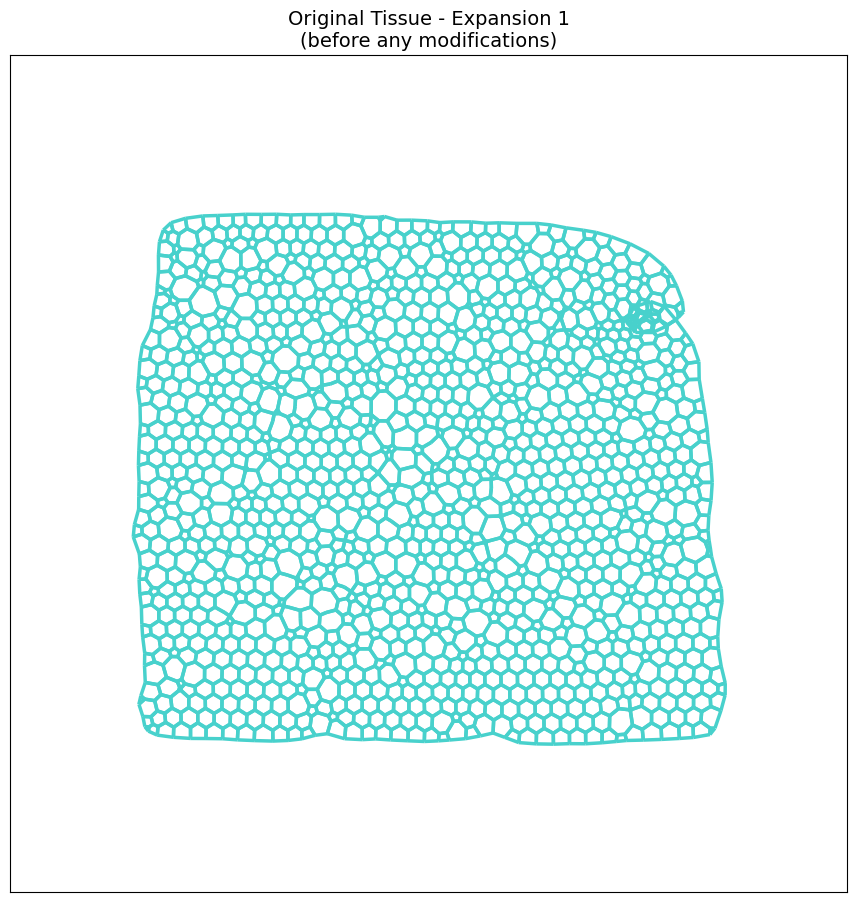


[Step 1] Growing tumour
   Selected 3 seed cells

 PLOT 2: Seeded tumour cells (before growth)


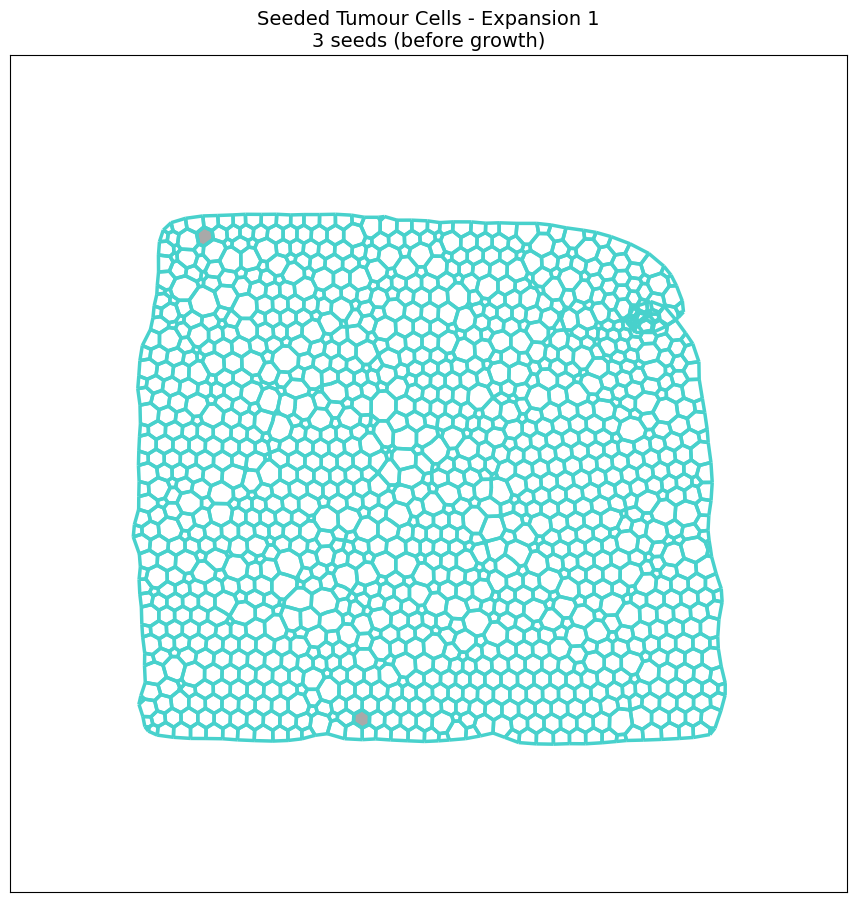


 Growing tumour (50 cells per seed)
   Final tumour size: 153 cells

 PLOT 3: Grown tumour (before relaxation)


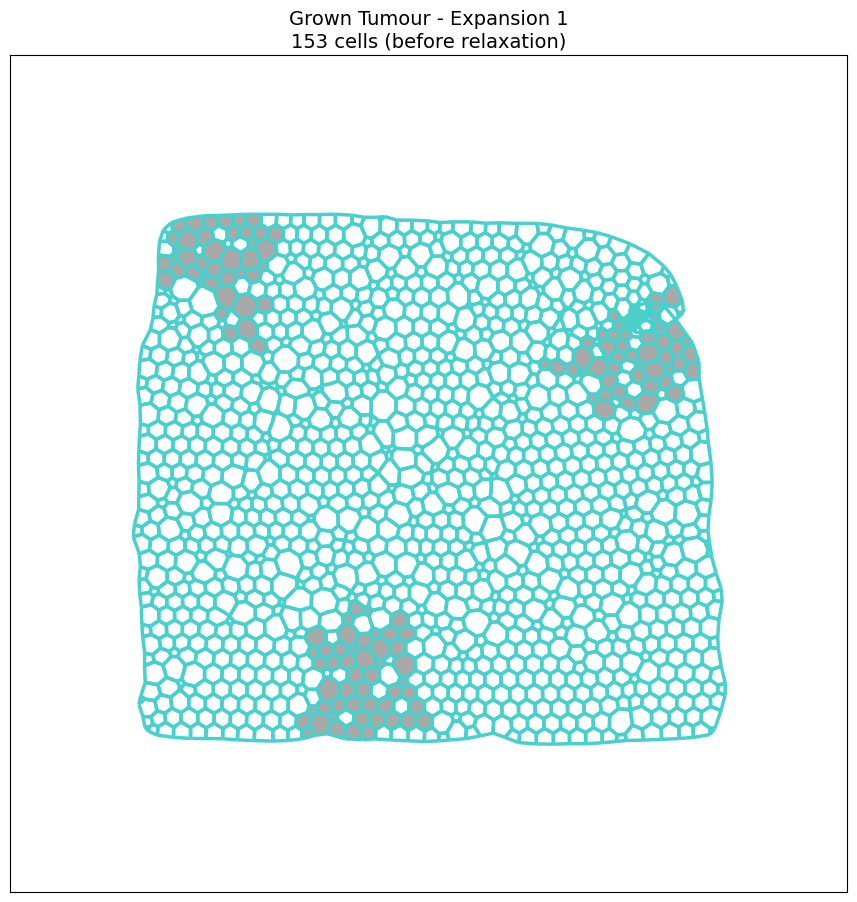


 Applying tumour mechanics

 Relaxing energy for 200 steps (after tumour)
Relaxing
Topology changed!


In [ ]:
# ============================================================================
# MAIN EXECUTION - Run Simulations
# ============================================================================

# Parameters for Figure 6 - Change these as needed
SCENARIO = 3  # Options: 1, 2, or 3
EXPANSION = 1  # Options: 1, 2, or 3
OUTPUT_DIR = "figure6_results"

params = {
    'seed': 42,
    'n_seeds': 3,
    'n_tumour_cells_per_seed': 50,
    'p_frontier': 0.9,
    'fibrosis_fraction': 0.5,
    'fibrosis_stiffness_factor': 2.0,
    'fibrosis_pl_factor': 0.5,
    'n_fibrotic_patches': 6,
    'division_threshold': 3.5,
    'relaxation_steps': 200,
    'post_division_steps': 200,
    'output_folder': OUTPUT_DIR,
}

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("\n" + "="*60)
print(f"FIGURE 6 SIMULATION")
print(f"Scenario: {SCENARIO} | Expansion: {EXPANSION}")
print("="*60)

# Step 1: Initialize tissue geometry and energy model
print("\n Initializing fresh tissue with geometry and energy model")
cellmap_init, geom, energyContributions_model = vertexModel2.initialize(40)
cellmap_init = MechanicalParams2.update(cellmap_init)

# Step 2: Load checkpoint data into the initialized cellmap
print(f"\n Loading checkpoint data (Expansion {EXPANSION})")
checkpoint_cellmap = load_checkpoint(EXPANSION)


# Reset topology to ensure consistency
checkpoint_cellmap.reset_index()
checkpoint_cellmap.reset_topo()

# Update geometry with the loaded data
geom.update_all(checkpoint_cellmap)
print("  Checkpoint data loaded into initialized structure")

# Debug: Check baseline area_elasticity before tumour growth
print(f"\n Baseline area_elasticity (before tumour):")
print(f"   Min: {checkpoint_cellmap.face_df['area_elasticity'].min()}")
print(f"   Max: {checkpoint_cellmap.face_df['area_elasticity'].max()}")
print(f"   Mean: {checkpoint_cellmap.face_df['area_elasticity'].mean():.2f}")

# Setup colormaps for plotting
setup_colormaps()

# Run selected scenario
if SCENARIO == 1:
    cellmap_final, tumour_faces, fibrotic_edges = run_scenario_1(
        checkpoint_cellmap, geom, energyContributions_model, params, EXPANSION
    )
elif SCENARIO == 2:
    cellmap_final, tumour_faces, fibrotic_edges = run_scenario_2(
        checkpoint_cellmap, geom, energyContributions_model, params, EXPANSION
    )
elif SCENARIO == 3:
    cellmap_final, tumour_faces, fibrotic_edges = run_scenario_3(
        checkpoint_cellmap, geom, energyContributions_model, params, EXPANSION
    )
else:
    raise ValueError(f"Unknown scenario: {SCENARIO}")

# Debug: Check area_elasticity after tumour mechanics
print(f"\n📊 area_elasticity after tumour growth and mechanics:")
print(f"   Min: {cellmap_final.face_df['area_elasticity'].min()}")
print(f"   Max: {cellmap_final.face_df['area_elasticity'].max()}")
print(f"   Mean: {cellmap_final.face_df['area_elasticity'].mean():.2f}")
print(f"   Number of tumour cells (> threshold): {(cellmap_final.face_df['area_elasticity'] > 100).sum()}")

# Final plot
print("\n" + "="*60)
print("Generating final figure")
print("="*60)

fig, ax = plot_tissue(
    cellmap_final,
    tumour_faces=tumour_faces,
    fibrotic_edges=fibrotic_edges,
    show_after_tumour_vertices=True,
    show_only_new_vertices=True,
    xlim=(-20, 60),
    ylim=(-20, 60),
    figsize=(15, 15),
    title=f"Scenario {SCENARIO} | Expansion {EXPANSION}\n"
          f"Tumour: {len(tumour_faces)} cells | Fibrosis: {len(fibrotic_edges)} edges",
    save_path=f"{OUTPUT_DIR}/figure6_scenario{SCENARIO}_exp{EXPANSION}.png"
)

plt.show()

# Print summary
print("\n" + "="*60)
print("SIMULATION COMPLETE")
print("="*60)
print(f"Scenario: {SCENARIO}")
print(f"Expansion replicate: {EXPANSION}")
print(f"Final tumour cells: {len(tumour_faces)}")
print(f"Fibrotic edges: {len(fibrotic_edges)}")
print(f"Output folder: {OUTPUT_DIR}")
print("="*60)